In [ ]:
from tqdm import tqdm
import torch

def train(model, epoch, train_loader, optimizer, criterion, device, scheduler):
    correct_ = []
    for ep in range(epoch):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        for images, labels in tqdm(train_loader, desc=f"训练中 [{ep+1}/{epoch}]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total
        correct_.append(accuracy)
        print(
            f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 准确率: {accuracy:.4f} total: {total} correct: {correct}"
        )

        try:
            scheduler.step(accuracy)
        except NameError:
            # 如果 notebook 中没有定义 scheduler，就跳过调度
            pass
    return correct_

In [17]:
def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="测试中"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"测试准确率: {accuracy:.4f}")

In [ ]:
from torch.utils.data import Dataset
import os
import torchvision.transforms as T
from PIL import Image


class DataSetLoader(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # 收集所有 (img_path, label_idx)
        self.samples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )  # 只取前 5 个类
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # 用 PIL 读图，更稳
        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)
        else:
            # 默认变换
            transform = T.Compose(
                [
                    T.Resize((256, 256)),
                    T.ToTensor(),
                ]
            )
            image = transform(image)

        return image, label

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt
from torchvision.models import ResNet50_Weights

train_dir = "/data/data_taohy/awesomeCopression/food101_images/train"
test_dir = "/data/data_taohy/awesomeCopression/food101_images/validation"


train_transform = T.Compose(
    [
        T.Resize(150),
        T.RandomResizedCrop(128),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

test_transform = T.Compose(
    [
        T.Resize(150),
        T.CenterCrop(128),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = DataSetLoader(root_dir=train_dir, transform=train_transform)
test_dataset = DataSetLoader(root_dir=test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8)
model = torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features # 获取全连接层输入特征数
model.fc = torch.nn.Linear(in_features, 101) # 替换全连接层，输出 101 类

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",  # 监控准确率（越大越好）
    factor=0.1,  # 乘以 0.1（即除以 10）
    patience=5,  # 等待 5 个 epoch 不改善才调整
)
criterion = torch.nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
    model = nn.DataParallel(model)
model.to(device)

使用多卡训练, GPU 数量: 4


DataParallel(
  (module): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [ ]:
correct = train(model, epoch=100, train_loader=train_loader, optimizer=optimizer, criterion=criterion, device=device, scheduler=scheduler)

训练中 [1/100]: 100%|██████████| 1184/1184 [03:00<00:00,  6.57it/s]


Epoch [1/100] 平均损失: 2.4649 准确率: 0.4104 total: 75750 correct: 31089


训练中 [2/100]: 100%|██████████| 1184/1184 [02:55<00:00,  6.74it/s]


Epoch [2/100] 平均损失: 1.7813 准确率: 0.5519 total: 75750 correct: 41804


训练中 [3/100]: 100%|██████████| 1184/1184 [02:59<00:00,  6.61it/s]


...

Epoch [98/100] 平均损失: 0.5087 准确率: 0.8666 total: 75750 correct: 65643


训练中 [99/100]: 100%|██████████| 1184/1184 [03:00<00:00,  6.57it/s]


Epoch [99/100] 平均损失: 0.5032 准确率: 0.8696 total: 75750 correct: 65873


训练中 [100/100]: 100%|██████████| 1184/1184 [03:04<00:00,  6.40it/s]

Epoch [100/100] 平均损失: 0.5050 准确率: 0.8675 total: 75750 correct: 65711


In [21]:
def show_correct(correct_):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(correct) + 1), correct, marker="o", linestyle="-")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy per Epoch")
    plt.grid(True)
    plt.xticks(range(1, len(correct) + 1))

    # 标注最佳点
    best_idx = max(range(len(correct)), key=lambda i: correct[i])
    best_acc = correct[best_idx]
    plt.scatter(best_idx + 1, best_acc, color="red")
    plt.annotate(
        f"best: {best_acc:.4f}",
        xy=(best_idx + 1, best_acc),
        xytext=(best_idx + 1, best_acc + 0.02),
        arrowprops=dict(arrowstyle="->", color="red"),
    )

    plt.show()

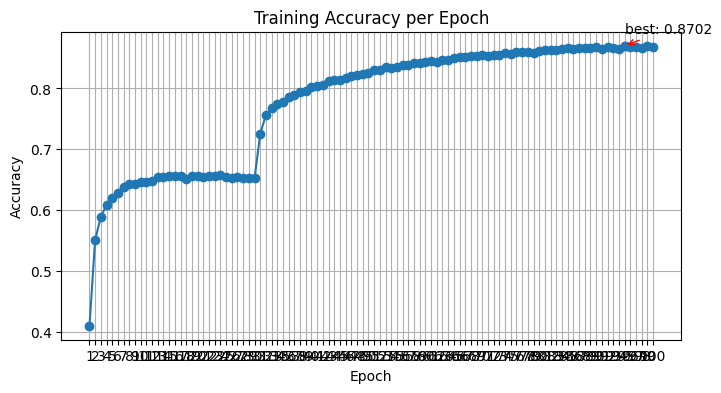

In [22]:
show_correct(correct)

In [23]:
test(model, test_loader=test_loader, device=device)

测试中: 100%|██████████| 395/395 [00:40<00:00,  9.86it/s]

测试准确率: 0.7975


In [ ]:
import os
from datetime import datetime

# 保存/加载检查点的实用函数（在新的 notebook cell 中执行）

def save_checkpoint(path, model, optimizer, scheduler=None, epoch=None, best_acc=None):
  os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
  # 如果使用了 DataParallel，保存 module 的 state_dict
  state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
  checkpoint = {
    "epoch": epoch,
    "model_state_dict": state_dict,
    "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "best_acc": best_acc,
    "saved_at": datetime.utcnow().isoformat(),
  }
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")


def load_checkpoint(path, model, optimizer=None, scheduler=None, map_location=device):
  checkpoint = torch.load(path, map_location=map_location)
  # 如果当前 model 是 DataParallel，需要把 state_dict 加载到 module
  target = model.module if hasattr(model, "module") else model
  target.load_state_dict(checkpoint["model_state_dict"])
  if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
  print(f"Loaded checkpoint from {path}, epoch={checkpoint.get('epoch')}, best_acc={checkpoint.get('best_acc')}")
  return checkpoint

save_checkpoint("/data/data_taohy/awesomeCopression/model/resnet_food101.pth", model, optimizer)
# ckpt = load_checkpoint("/data/data_taohy/awesomeCopression/model/alexnet_food101.pth", model, optimizer, scheduler)

Saved checkpoint to /data/data_taohy/awesomeCopression/model/alexnet_food101.pth


In [ ]:
def load_checkpoint(path, model, optimizer=None, scheduler=None, map_location=device):
  checkpoint = torch.load(path, map_location=map_location)
  # 如果当前 model 是 DataParallel，需要把 state_dict 加载到 module
  target = model.module if hasattr(model, "module") else model
  target.load_state_dict(checkpoint["model_state_dict"])
  if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
  if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
  print(f"Loaded checkpoint from {path}, epoch={checkpoint.get('epoch')}, best_acc={checkpoint.get('best_acc')}")
  return checkpoint